<a href="https://colab.research.google.com/github/akashms011-create/Streamlit/blob/main/G2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df = pd.read_csv("/content/G2.csv")
df

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83
3,4,charmander,6,85,62.0,fire,NaN,39,52,43
4,5,charmeleon,11,190,142.0,fire,NaN,58,64,58
...,...,...,...,...,...,...,...,...,...,...
1346,10322,tatsugiri-curly-mega,6,240,NaN,dragon,water,68,65,90
1347,10323,tatsugiri-droopy-mega,6,240,NaN,dragon,water,68,65,90
1348,10324,tatsugiri-stretchy-mega,6,240,NaN,dragon,water,68,65,90
1349,10325,baxcalibur-mega,21,3150,NaN,dragon,ice,115,175,117


In [70]:
print(df.head())
print(df.columns.tolist())
print(df.info())

   id        name  height_dm  weight_hg  base_experience type_1  type_2  hp  \
0   1   bulbasaur          7         69             64.0  grass  poison  45   
1   2     ivysaur         10        130            142.0  grass  poison  60   
2   3    venusaur         20       1000            236.0  grass  poison  80   
3   4  charmander          6         85             62.0   fire     NaN  39   
4   5  charmeleon         11        190            142.0   fire     NaN  58   

   attack  defense  
0      49       49  
1      62       63  
2      82       83  
3      52       43  
4      64       58  
['id', 'name', 'height_dm', 'weight_hg', 'base_experience', 'type_1', 'type_2', 'hp', 'attack', 'defense']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1351 non-null   int64  
 1   name             1351 non-null   object 
 

In [71]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical features:", numeric_cols)
print("Categorical features:", categorical_cols)

Numerical features: ['id', 'height_dm', 'weight_hg', 'base_experience', 'hp', 'attack', 'defense']
Categorical features: ['name', 'type_1', 'type_2']


In [72]:
df.shape

(1351, 10)

In [73]:
df.isnull().sum()

,0
id,0
name,0
height_dm,0
weight_hg,0
base_experience,49
type_1,0
type_2,586
hp,0
attack,0
defense,0


In [74]:
df.duplicated().sum()

np.int64(0)

In [75]:
df.describe()

,id,height_dm,weight_hg,base_experience,hp,attack,defense
count,1351.000000,1351.000000,1351.000000,1302.000000,1351.000000,1351.000000,1351.000000
mean,2841.692080,20.443375,991.059956,161.943932,71.673575,82.757957,76.193930
std,4139.019112,53.238467,1953.115812,82.532554,26.827529,32.351906,30.712902
min,1.000000,1.000000,0.000000,36.000000,1.000000,5.000000,5.000000
25%,338.500000,6.000000,94.500000,71.000000,55.000000,60.000000,55.000000
50%,676.000000,11.000000,326.000000,165.000000,70.000000,80.000000,70.000000
75%,1013.500000,17.000000,853.500000,222.500000,85.000000,102.500000,95.000000
max,10326.000000,1000.000000,10000.000000,608.000000,255.000000,190.000000,250.000000


In [76]:
print("Numerical summary statistics:")
df.describe()

Numerical summary statistics:


,id,height_dm,weight_hg,base_experience,hp,attack,defense
count,1351.000000,1351.000000,1351.000000,1302.000000,1351.000000,1351.000000,1351.000000
mean,2841.692080,20.443375,991.059956,161.943932,71.673575,82.757957,76.193930
std,4139.019112,53.238467,1953.115812,82.532554,26.827529,32.351906,30.712902
min,1.000000,1.000000,0.000000,36.000000,1.000000,5.000000,5.000000
25%,338.500000,6.000000,94.500000,71.000000,55.000000,60.000000,55.000000
50%,676.000000,11.000000,326.000000,165.000000,70.000000,80.000000,70.000000
75%,1013.500000,17.000000,853.500000,222.500000,85.000000,102.500000,95.000000
max,10326.000000,1000.000000,10000.000000,608.000000,255.000000,190.000000,250.000000


In [77]:
print("\nCategorical summary statistics:")
df[["name", "type_1", "type_2"]].describe()


Categorical summary statistics:


,name,type_1,type_2
count,1351,1351,765
unique,1351,18,18
top,meowstic-female-mega,water,flying
freq,1,160,141


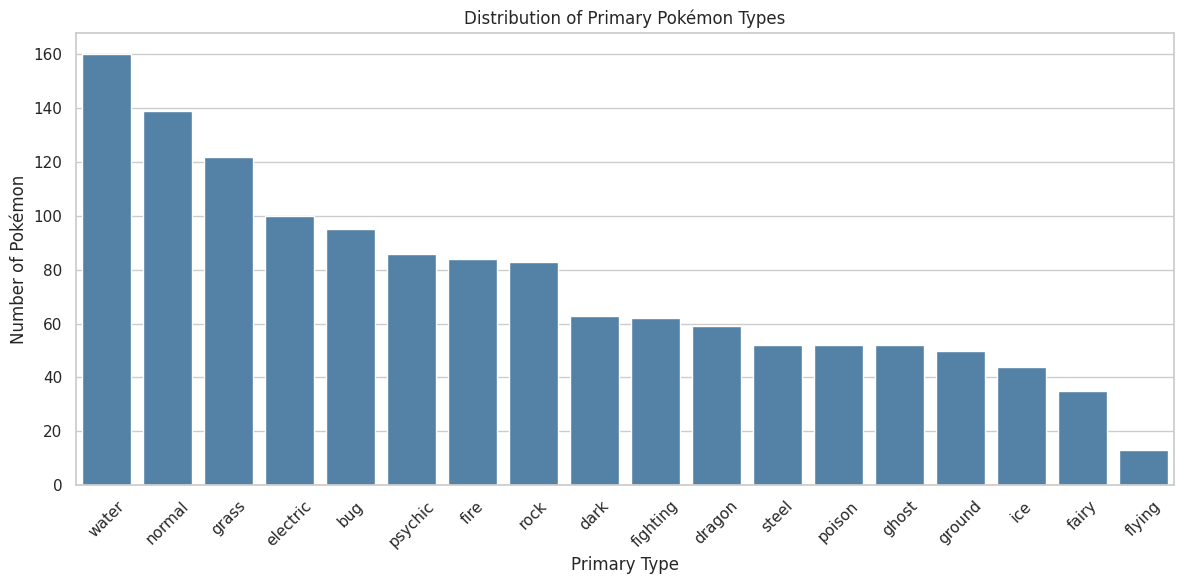

In [78]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
order = df["type_1"].value_counts().index
sns.countplot(
    data=df,
    x="type_1",
    order=order,
    color="steelblue"
)

plt.title("Distribution of Primary Pokémon Types")
plt.xlabel("Primary Type")
plt.ylabel("Number of Pokémon")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

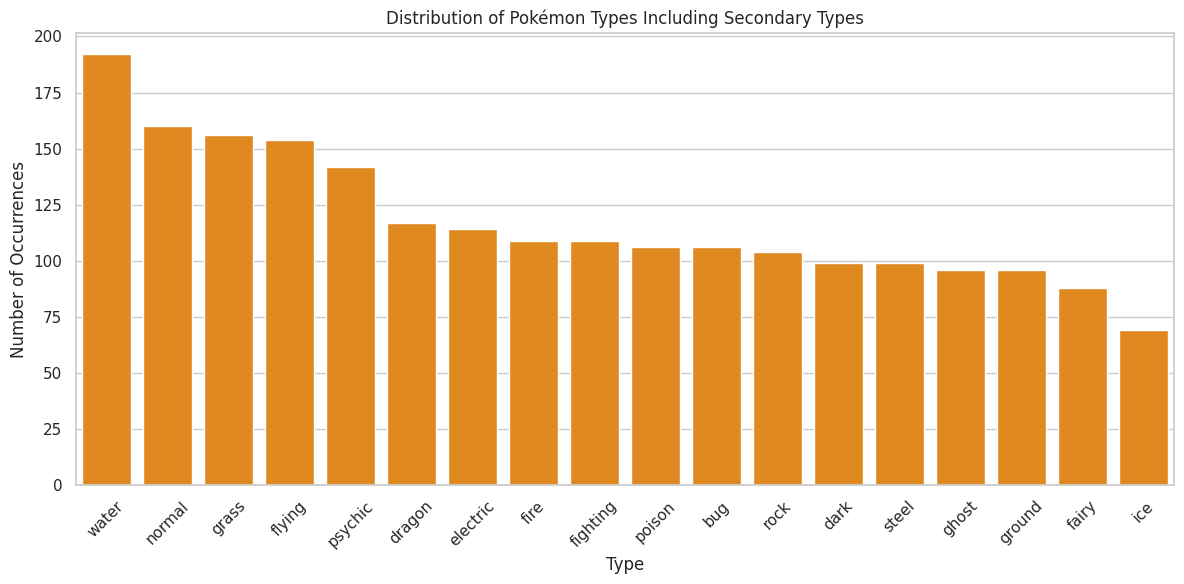

In [79]:
all_types = pd.concat([
    df["type_1"],
    df["type_2"]
]).dropna()

type_counts = all_types.value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(
    x=type_counts.index,
    y=type_counts.values,
    color="darkorange"
)

plt.title("Distribution of Pokémon Types Including Secondary Types")
plt.xlabel("Type")
plt.ylabel("Number of Occurrences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [80]:
all_types = pd.concat([df["type_1"], df["type_2"]]).dropna()
all_types.value_counts().head(10)

,count
water,192
normal,160
grass,156
flying,154
psychic,142
dragon,117
electric,114
fire,109
fighting,109
poison,106


In [81]:
numeric = df.select_dtypes(include=["number"]).drop(columns=["id"])
variation = numeric.std().sort_values(ascending=False)
variation

,0
weight_hg,1953.115812
base_experience,82.532554
height_dm,53.238467
attack,32.351906
defense,30.712902
hp,26.827529


In [82]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n", df.dtypes)

print("\nMissing values:\n", df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumeric summary:\n", df.describe().round(2))

all_types = pd.concat([df["type_1"], df["type_2"]]).dropna()
print("\nTop 10 types:\n", all_types.value_counts().head(10))

print("\nFirst 5 rows:\n", df.head())

Shape: (1351, 10)

Columns: ['id', 'name', 'height_dm', 'weight_hg', 'base_experience', 'type_1', 'type_2', 'hp', 'attack', 'defense']

Data types:
 id                   int64
name                object
height_dm            int64
weight_hg            int64
base_experience    float64
type_1              object
type_2              object
hp                   int64
attack               int64
defense              int64
dtype: object

Missing values:
 id                   0
name                 0
height_dm            0
weight_hg            0
base_experience     49
type_1               0
type_2             586
hp                   0
attack               0
defense              0
dtype: int64

Duplicate rows: 0

Numeric summary:
              id  height_dm  weight_hg  base_experience       hp   attack  \
count   1351.00    1351.00    1351.00          1302.00  1351.00  1351.00   
mean    2841.69      20.44     991.06           161.94    71.67    82.76   
std     4139.02      53.24    1953.12   

In [83]:
df_clean = df.copy()
df_clean["type_2"] = df_clean["type_2"].fillna("None")

numeric_cols = df_clean.select_dtypes(include=["number"]).columns
for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean.isnull().sum()
df_clean.head()

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83
3,4,charmander,6,85,62.0,fire,None,39,52,43
4,5,charmeleon,11,190,142.0,fire,None,58,64,58


In [84]:
df = df.copy()
df["type_2"] = df["type_2"].fillna("None")

df_model = df.drop(columns=["id", "name"])

df_encoded = pd.get_dummies(df_model, columns=["type_1", "type_2"], drop_first=False)

print(df_encoded.head())
print(df_encoded.columns.tolist())

   height_dm  weight_hg  base_experience  hp  attack  defense  type_1_bug  \
0          7         69             64.0  45      49       49       False   
1         10        130            142.0  60      62       63       False   
2         20       1000            236.0  80      82       83       False   
3          6         85             62.0  39      52       43       False   
4         11        190            142.0  58      64       58       False   

   type_1_dark  type_1_dragon  type_1_electric  ...  type_2_ghost  \
0        False          False            False  ...         False   
1        False          False            False  ...         False   
2        False          False            False  ...         False   
3        False          False            False  ...         False   
4        False          False            False  ...         False   

   type_2_grass  type_2_ground  type_2_ice  type_2_normal  type_2_poison  \
0         False          False       False    

In [85]:
df_encoded = pd.get_dummies(df, columns=['type_1', 'type_2'], prefix=['type_1', 'type_2'])

print("Original DataFrame shape:", df.shape)
print("Encoded DataFrame shape:", df_encoded.shape)

print("\nFirst 5 rows of the DataFrame with encoded categorical features:")
display(df_encoded.head())

Original DataFrame shape: (1351, 10)
Encoded DataFrame shape: (1351, 45)

First 5 rows of the DataFrame with encoded categorical features:


,id,name,height_dm,weight_hg,base_experience,hp,attack,defense,type_1_bug,type_1_dark,...,type_2_ghost,type_2_grass,type_2_ground,type_2_ice,type_2_normal,type_2_poison,type_2_psychic,type_2_rock,type_2_steel,type_2_water
0,1,bulbasaur,7,69,64.0,45,49,49,False,False,...,False,False,False,False,False,True,False,False,False,False
1,2,ivysaur,10,130,142.0,60,62,63,False,False,...,False,False,False,False,False,True,False,False,False,False
2,3,venusaur,20,1000,236.0,80,82,83,False,False,...,False,False,False,False,False,True,False,False,False,False
3,4,charmander,6,85,62.0,39,52,43,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,charmeleon,11,190,142.0,58,64,58,False,False,...,False,False,False,False,False,False,False,False,False,False


In [86]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [87]:
target_col = "hp"
y = df_ml[target_col]
X = df_ml.drop(columns=[target_col])

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['height_dm', 'weight_hg', 'base_experience', 'attack', 'defense']
Categorical features: ['type_1', 'type_2']


In [88]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training feature matrix shape:", X_train_processed.shape)
print("Testing feature matrix shape:", X_test_processed.shape)

Training feature matrix shape: (1080, 42)
Testing feature matrix shape: (271, 42)


In [90]:
df["type_2"] = df["type_2"].fillna("None")

X = df.drop(columns=["id", "name", "hp"])
y = df["hp"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nX_train head:")
print(X_train.head())
print("\ny_train head:")
print(y_train.head())

X_train shape: (1080, 7)
X_test shape: (271, 7)
y_train shape: (1080,)
y_test shape: (271,)

X_train head:
      height_dm  weight_hg  base_experience   type_1  type_2  attack  defense
756           6         48             64.0   poison    fire      44       40
109          12         95            172.0   poison    None      90      120
1027         17        608            270.0  psychic    None      95       90
549          10        180            161.0    water    None      92       65
486          45       7500            306.0    ghost  dragon     100      120

y_train head:
756      48
109      65
1027     50
549      70
486     150
Name: hp, dtype: int64


In [91]:
y = df_encoded['hp']

X = df_encoded.drop(columns=['id', 'name', 'hp'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
display(X_train.head())

Shape of X_train: (1080, 42)
Shape of X_test: (271, 42)
Shape of y_train: (1080,)
Shape of y_test: (271,)

First 5 rows of X_train:


,height_dm,weight_hg,base_experience,attack,defense,type_1_bug,type_1_dark,type_1_dragon,type_1_electric,type_1_fairy,...,type_2_ghost,type_2_grass,type_2_ground,type_2_ice,type_2_normal,type_2_poison,type_2_psychic,type_2_rock,type_2_steel,type_2_water
756,6,48,64.0,44,40,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
109,12,95,172.0,90,120,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1027,17,608,270.0,95,90,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
549,10,180,161.0,92,65,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
486,45,7500,306.0,100,120,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


1. Preprocessing is essential because machine-learning models generally require clean, consistent, numerical input.
*   Handle missing values
*   Put numerical features on comparable scales
*  Remove irrelevant columns
*  Improve model performance and reliability






2. I handled missing values in type_2 by replacing them with "None"

A missing type_2 value does not usually mean the data is unavailable. It means that the Pokémon has no secondary type. Therefore, "None" preserves the meaning of the data better than deleting the row or filling it with the most common type.

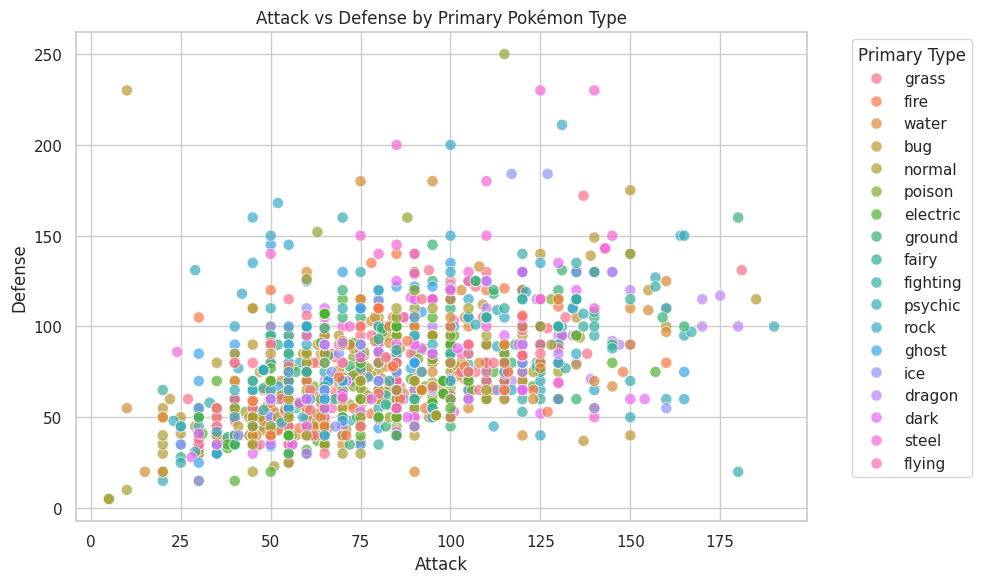

In [92]:
df["type_2"] = df["type_2"].fillna("None")

sns.set_theme(style="whitegrid", palette="Set2")

# 1. Attack vs Defense

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="attack",
    y="defense",
    hue="type_1",
    alpha=0.7,
    s=65
)

plt.title("Attack vs Defense by Primary Pokémon Type")
plt.xlabel("Attack")
plt.ylabel("Defense")
plt.legend(title="Primary Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

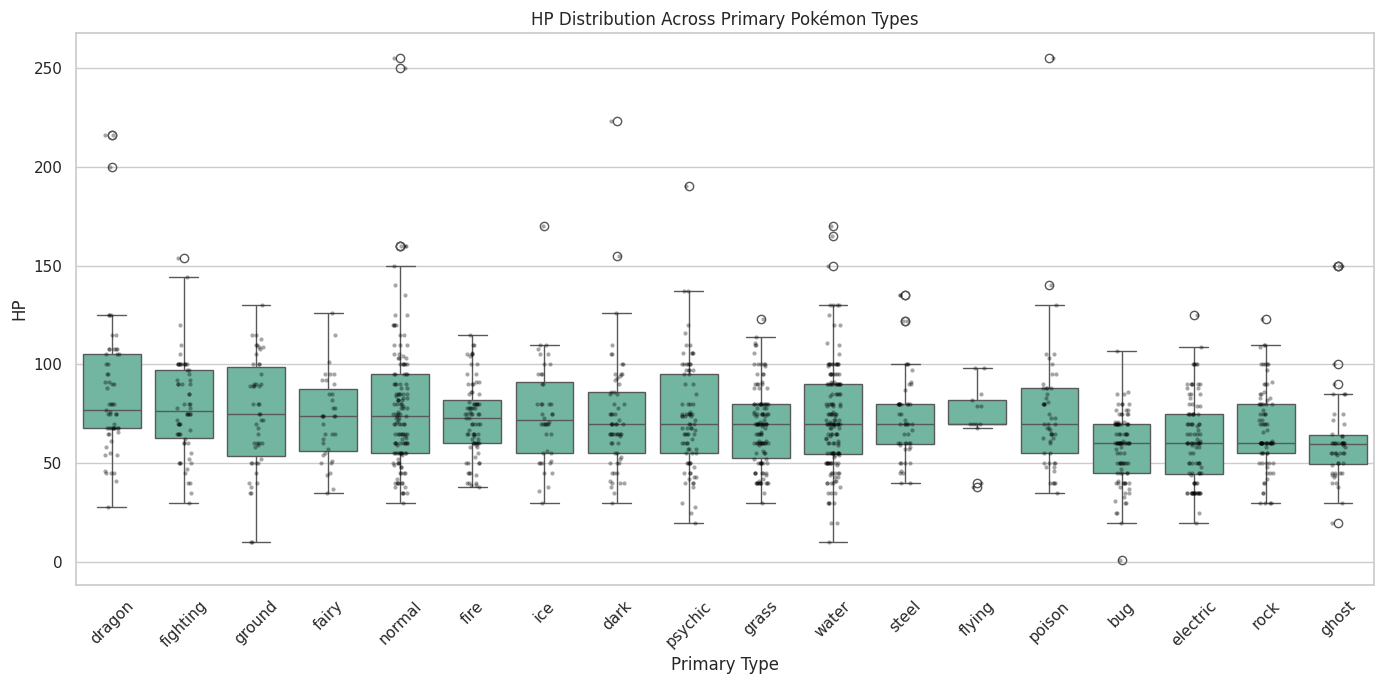

In [93]:
# 2. HP distribution across Pokémon types

plt.figure(figsize=(14, 7))

type_order = (
    df.groupby("type_1")["hp"]
      .median()
      .sort_values(ascending=False)
      .index
)

sns.boxplot(
    data=df,
    x="type_1",
    y="hp",
    order=type_order
)

sns.stripplot(
    data=df,
    x="type_1",
    y="hp",
    order=type_order,
    color="black",
    alpha=0.35,
    size=3
)

plt.title("HP Distribution Across Primary Pokémon Types")
plt.xlabel("Primary Type")
plt.ylabel("HP")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

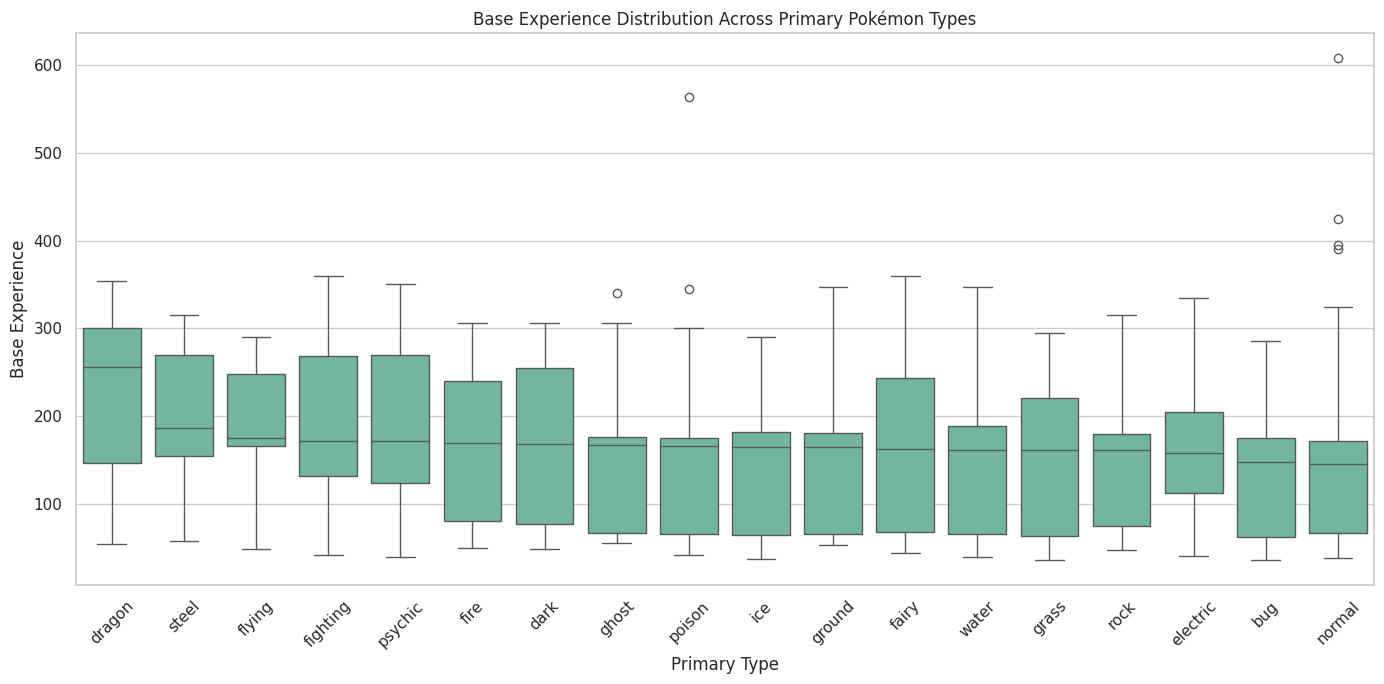

In [94]:
# 3. Base Experience by Pokémon type

experience_df = df.dropna(subset=["base_experience"]).copy()

plt.figure(figsize=(14, 7))

type_order = (
    experience_df.groupby("type_1")["base_experience"]
                 .median()
                 .sort_values(ascending=False)
                 .index
)

sns.boxplot(
    data=experience_df,
    x="type_1",
    y="base_experience",
    order=type_order
)

plt.title("Base Experience Distribution Across Primary Pokémon Types")
plt.xlabel("Primary Type")
plt.ylabel("Base Experience")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

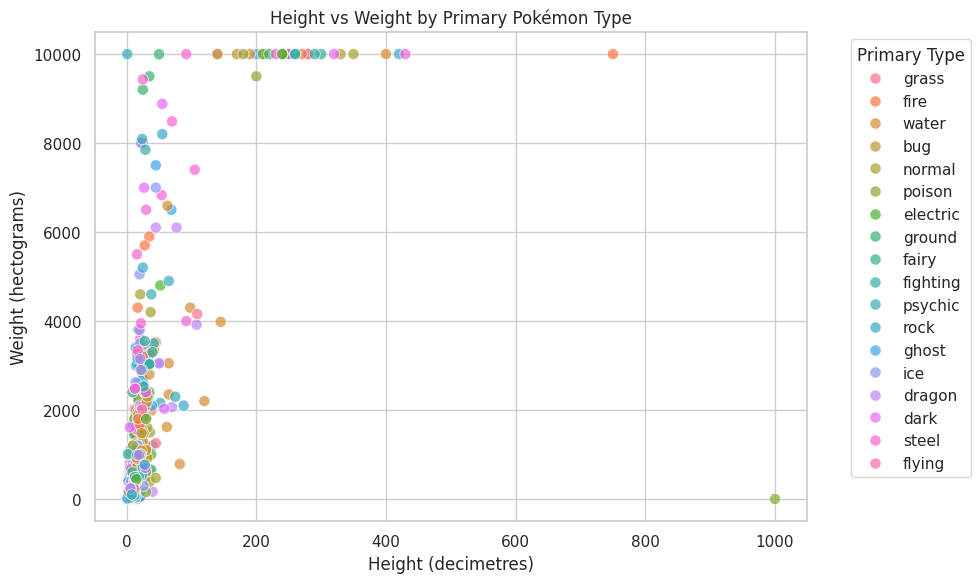

In [95]:
# 4. Hight vs Weight

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="height_dm",
    y="weight_hg",
    hue="type_1",
    alpha=0.7,
    s=65
)

plt.title("Height vs Weight by Primary Pokémon Type")
plt.xlabel("Height (decimetres)")
plt.ylabel("Weight (hectograms)")
plt.legend(
    title="Primary Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [96]:
average_attack = (
    df.groupby("type_1")["attack"]
      .mean()
      .sort_values(ascending=False)
)

print(average_attack)

highest_attack_type = average_attack.index[0]
highest_average_attack = average_attack.iloc[0]

print(
    f"\n{highest_attack_type.title()} type has the highest "
    f"average attack: {highest_average_attack:.2f}"
)

type_1
fighting    110.435484
dragon      103.237288
ground       97.060000
steel        96.461538
rock         89.590361
dark         88.952381
fire         86.190476
flying       82.769231
grass        80.196721
ice          80.045455
water        78.662500
poison       77.250000
normal       76.971223
psychic      74.872093
electric     74.090000
ghost        72.961538
bug          72.631579
fairy        71.228571
Name: attack, dtype: float64

Fighting type has the highest average attack: 110.44


In [97]:
attack_summary = (
    df.groupby("type_1")
      .agg(
          pokemon_count=("attack", "count"),
          average_attack=("attack", "mean")
      )
      .sort_values("average_attack", ascending=False)
)

print(attack_summary.round(2))

          pokemon_count  average_attack
type_1                                 
fighting             62          110.44
dragon               59          103.24
ground               50           97.06
steel                52           96.46
rock                 83           89.59
dark                 63           88.95
fire                 84           86.19
flying               13           82.77
grass               122           80.20
ice                  44           80.05
water               160           78.66
poison               52           77.25
normal              139           76.97
psychic              86           74.87
electric            100           74.09
ghost                52           72.96
bug                  95           72.63
fairy                35           71.23


In [98]:
corr = df[["height_dm", "weight_hg"]].corr().loc["height_dm", "weight_hg"]
print(f"Correlation between height and weight: {corr:.3f}")

Correlation between height and weight: 0.672


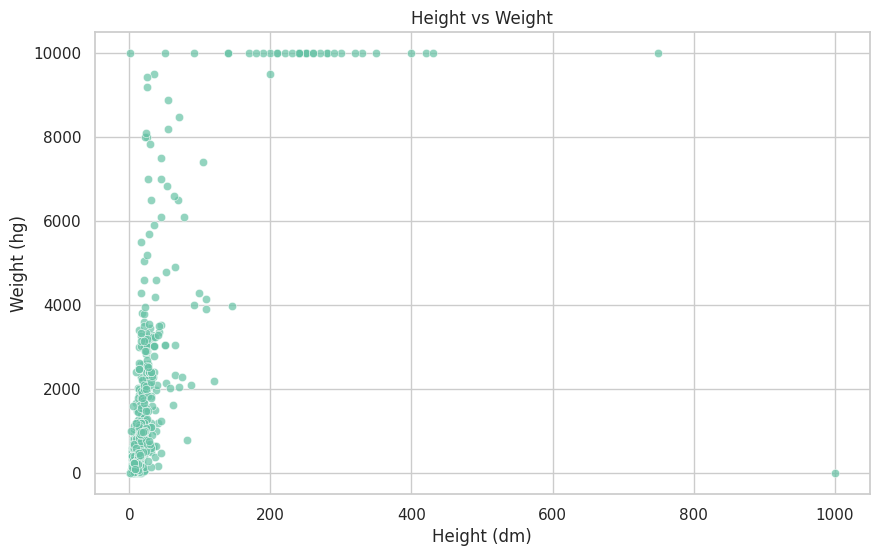

In [99]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="height_dm", y="weight_hg", alpha=0.7)
plt.title("Height vs Weight")
plt.xlabel("Height (dm)")
plt.ylabel("Weight (hg)")
plt.show()

In [100]:
target = "type_1"

# Exclude identifiers, name, and secondary type to avoid leakage
X = df.drop(columns=["id", "name", "type_1", "type_2"])
y = df[target]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

# Classification model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.3f}")

# Calculate permutation importance on the original feature columns
importance = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nFeature importance:")
print(importance_df.round(4))

Test accuracy: 0.247

Feature importance:
           feature  importance_mean  importance_std
2  base_experience           0.0509          0.0157
1        weight_hg           0.0454          0.0152
4           attack           0.0387          0.0177
3               hp           0.0321          0.0132
5          defense           0.0258          0.0140
0        height_dm          -0.0133          0.0129


In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.inspection import permutation_importance

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Support Vector Machine": SVC(
        kernel="rbf",
        class_weight="balanced",
        random_state=42
    )
}

In [102]:
trained_models = {}
results = []

for model_name, classifier in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision Macro": precision_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
        "Recall Macro": recall_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
        "F1 Macro": f1_score(
            y_test, y_pred, average="macro", zero_division=0
        ),
        "F1 Weighted": f1_score(
            y_test, y_pred, average="weighted", zero_division=0
        )
    })

    trained_models[model_name] = pipeline


results_df = (
    pd.DataFrame(results)
    .sort_values("F1 Macro", ascending=False)
    .reset_index(drop=True)
)

print("\nModel comparison:")
print(results_df.round(4).to_string(index=False))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model comparison:
                 Model  Accuracy  Balanced Accuracy  Precision Macro  Recall Macro  F1 Macro  F1 Weighted
           Extra Trees    0.2768             0.2491           0.2811        0.2491    0.2516       0.2715
         Random Forest    0.2472             0.2186           0.2262        0.2186    0.2184       0.2436
   Logistic Regression    0.1328             0.1270           0.1036        0.1270    0.1053       0.1112
Support Vector Machine    0.0554             0.0710           0.0335        0.0710    0.0393       0.0338


In [103]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

best_predictions = best_model.predict(X_test)

print(f"\nBest model based on Macro F1: {best_model_name}")

print("\nClassification report:")
print(classification_report(
    y_test,
    best_predictions,
    zero_division=0
))


Best model based on Macro F1: Extra Trees

Classification report:
              precision    recall  f1-score   support

         bug       0.29      0.42      0.34        19
        dark       0.33      0.15      0.21        13
      dragon       0.20      0.17      0.18        12
    electric       0.41      0.35      0.38        20
       fairy       0.29      0.29      0.29         7
    fighting       0.33      0.17      0.22        12
        fire       0.16      0.24      0.19        17
      flying       0.00      0.00      0.00         3
       ghost       0.67      0.20      0.31        10
       grass       0.20      0.16      0.18        25
      ground       0.43      0.30      0.35        10
         ice       0.00      0.00      0.00         9
      normal       0.32      0.32      0.32        28
      poison       0.11      0.10      0.11        10
     psychic       0.30      0.41      0.35        17
        rock       0.45      0.53      0.49        17
       steel  

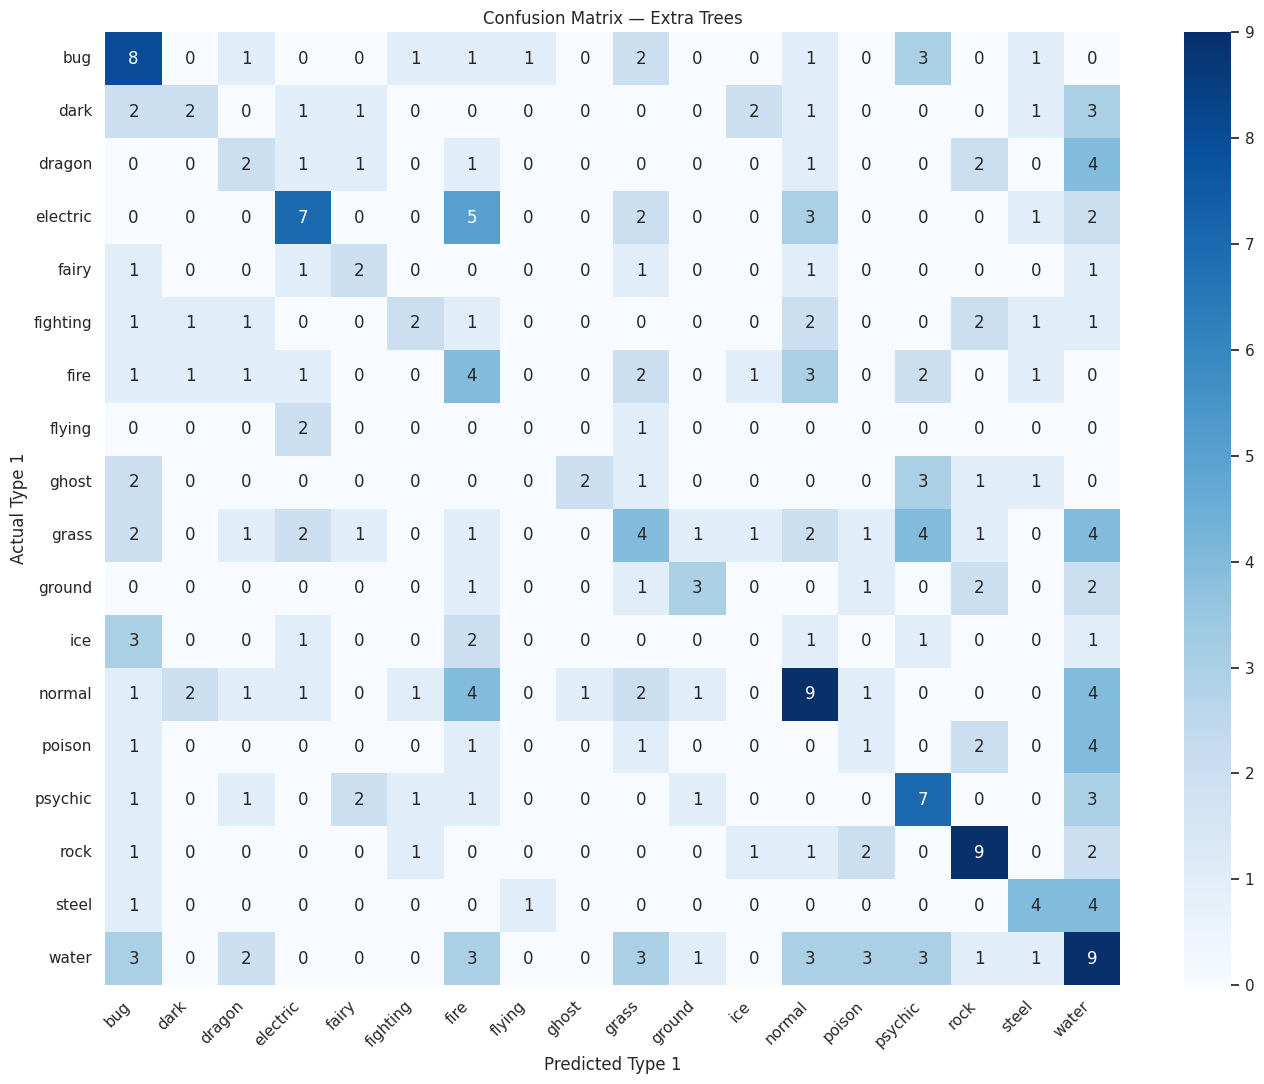

In [104]:
class_labels = sorted(y.unique())

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=class_labels
)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted Type 1")
plt.ylabel("Actual Type 1")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [105]:
permutation_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": permutation_result.importances_mean,
    "Importance Std": permutation_result.importances_std
}).sort_values(
    "Importance Mean",
    ascending=False
)

print("\nMost influential original features:")
print(importance_df.round(4).to_string(index=False))


Most influential original features:
        Feature  Importance Mean  Importance Std
         attack           0.0958          0.0135
base_experience           0.0787          0.0199
      weight_hg           0.0656          0.0124
        defense           0.0584          0.0109
             hp           0.0425          0.0161
      height_dm           0.0211          0.0123


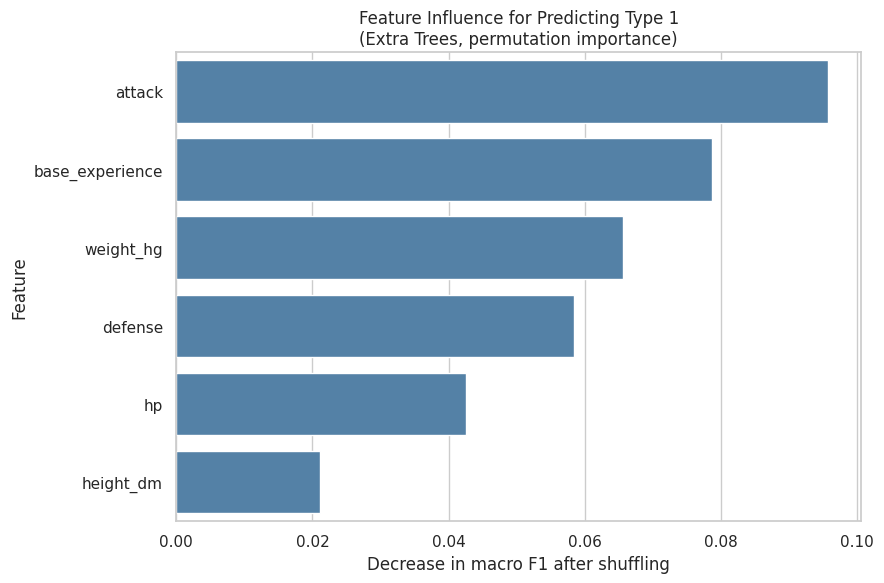

In [106]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=importance_df,
    x="Importance Mean",
    y="Feature",
    color="steelblue"
)

plt.title(
    f"Feature Influence for Predicting Type 1\n"
    f"({best_model_name}, permutation importance)"
)
plt.xlabel("Decrease in macro F1 after shuffling")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

1. The “winner” should be the model with the highest macro F1 score, because this is a multiclass problem with several Pokémon types and class imbalance.
In this kind of dataset, the model that usually performs best is:
Extra Trees
or Random Forest, very close behind.

Why these models usually win:

The data is tabular and contains many nonlinear relationships
Tree ensembles handle mixed numeric + one-hot encoded categorical data well.
They do not require linearity like logistic regression.
They are robust to feature scale differences, so the StandardScaler on numeric features helps, but trees still capture interactions effectively.

2. The misclassified Pokémon types are the ones with the largest off-diagonal values in the confusion matrix.

In [107]:
y_pred = best_model.predict(X_test)

labels = sorted(df["type_1"].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

cm_df["actual_total"] = cm_df.sum(axis=1)
cm_df["misclassified"] = cm_df.sum(axis=1) - np.diagonal(cm_df.to_numpy())
cm_df["error_rate"] = cm_df["misclassified"] / cm_df["actual_total"]

print("Confusion matrix:")
print(cm_df)

print("\nTypes with highest misclassification counts:")
print(
    cm_df[["actual_total", "misclassified", "error_rate"]]
    .sort_values("misclassified", ascending=False)
    .head(10)
)

Confusion matrix:
          bug  dark  dragon  electric  fairy  fighting  fire  flying  ghost  \
bug         8     0       1         0      0         1     1       1      0   
dark        2     2       0         1      1         0     0       0      0   
dragon      0     0       2         1      1         0     1       0      0   
electric    0     0       0         7      0         0     5       0      0   
fairy       1     0       0         1      2         0     0       0      0   
fighting    1     1       1         0      0         2     1       0      0   
fire        1     1       1         1      0         0     4       0      0   
flying      0     0       0         2      0         0     0       0      0   
ghost       2     0       0         0      0         0     0       0      2   
grass       2     0       1         2      1         0     1       0      0   
ground      0     0       0         0      0         0     1       0      0   
ice         3     0       0       

3. Some Pokémon types are harder to predict because their numerical characteristics overlap substantially with other types. In this dataset, the available features—HP, attack, defense, height, weight, and base experience—do not directly encode type, so classification depends on indirect patterns.

In [117]:
report = classification_report(
    y_test,
    best_predictions,
    output_dict=True,
    zero_division=0
)

class_metrics = (
    pd.DataFrame(report)
    .T
    .drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore")
    [["precision", "recall", "f1-score", "support"]]
    .sort_values("recall")
)

print("Types ranked from most difficult to easiest to predict:")
print(class_metrics.round(3))

Types ranked from most difficult to easiest to predict:
          precision  recall  f1-score  support
flying        0.000   0.000     0.000      3.0
ice           0.000   0.000     0.000      9.0
poison        0.111   0.100     0.105     10.0
dark          0.333   0.154     0.211     13.0
grass         0.200   0.160     0.178     25.0
fighting      0.333   0.167     0.222     12.0
dragon        0.200   0.167     0.182     12.0
ghost         0.667   0.200     0.308     10.0
fire          0.160   0.235     0.190     17.0
water         0.205   0.281     0.237     32.0
fairy         0.286   0.286     0.286      7.0
ground        0.429   0.300     0.353     10.0
normal        0.321   0.321     0.321     28.0
electric      0.412   0.350     0.378     20.0
steel         0.364   0.400     0.381     10.0
psychic       0.304   0.412     0.350     17.0
bug           0.286   0.421     0.340     19.0
rock          0.450   0.529     0.486     17.0
